In [1]:
import numpy as np
import numpy.random as rand

In [2]:
true = np.random.randint(0,10,10)
prediction = np.random.randint(0,10,10)

print("массив истинных значений", true)
print("Массив предсказанных значений", prediction)

массив истинных значений [2 2 0 4 1 7 0 6 4 7]
Массив предсказанных значений [0 4 4 8 2 9 1 1 9 6]


In [3]:
# MSE

mse = (sum((tr - pred) ** 2 for tr, pred in zip(true, prediction))) / true.shape

mse

array([9.7])

In [4]:
# MAE

mae = (sum(abs(tr - pred) for tr, pred in zip(true, prediction))) / true.shape

mae

array([2.7])

In [5]:
# check with median

median = np.repeat(np.median(true), 10)

mse_median = (sum((tr - pred) ** 2 for tr, pred in zip(true, median))) / true.shape

mae_median = (sum(abs(tr - pred) for tr, pred in zip(true, median))) / true.shape

print("mse median = ", mse_median)
print("mae median = ", mae_median)

mse median =  [6.7]
mae median =  [2.3]


In [6]:
true_f1 = np.random.choice(a = [True, False], size = 10)
prediction_f1 = np.random.choice(a = [True, False], size = 10)

print("массив истинных значений", true_f1)
print("Массив предсказанных значений", prediction_f1)

массив истинных значений [ True  True  True  True  True False False False  True False]
Массив предсказанных значений [False False False False  True False False False  True False]


In [7]:
# f1

tp = true_f1 * prediction_f1
tp = tp.sum()
print("True positive: ", tp)

tn = true_f1 + prediction_f1
tn = tn.shape - tn.sum()
tn = np.array(tn).item()
print("True negative: ", tn)

fp: int = 0
    
for (tr, pred) in zip(true_f1, prediction_f1):
    if tr == False and pred == True:
        fp += 1
        
print("False positive: ", fp)

fn: int = 0
    
for (tr, pred) in zip(true_f1, prediction_f1):
    if tr == True and pred == False:
        fn += 1
        
print("False negative: ", fn)

precision = tp / (tp + fp)

recall = tp / (tp + fn)

print("f1 = ", 2 * precision * recall / (recall + precision))

True positive:  2
True negative:  4
False positive:  0
False negative:  4
f1 =  0.5


In [8]:
import pandas as pd
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn import datasets, linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [9]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep='\s+', skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]
X = data
y = target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg = linear_model.LinearRegression()

reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

mse

24.291119474973247

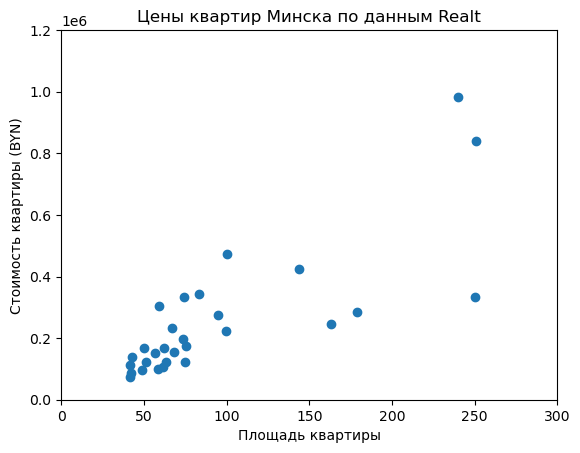

In [10]:
import pandas as pd
import seaborn as sns

X = np.array([42.9, 68.2, 74.1, 73.5, 94.8, 163, 63.2, 48.7, 61.4, 75.5, 61.9, 58.2, 75, 41.2, 179, 83.3, 99.6, 144, 56.4, 59.1, 250, 251, 
              42.1, 240, 50, 51, 100, 67, 41.3])
y = np.array([137591, 155504, 332660, 196840, 275576, 246050, 121057, 95271, 107278, 173022, 168298, 98223, 122041, 112337, 285418, 344470, 222429, 423206, 
              152551, 305102, 332660, 840507, 86177, 984200, 167117, 122041, 472416, 234240, 74799])

plt.scatter(x=X, y=y)

plt.xlabel("Площадь квартиры")
plt.ylabel("Стоимость квартиры (BYN)")
plt.title("Цены квартир Минска по данным Realt")
plt.xlim(0, 300)
plt.ylim(0, 1200000)

plt.show()

<h1> Linear regression: y = a + bX <h1>
<h1> MSE: (sum(yt - ypred) ** 2) / 2 <h1>

In [17]:
def linear_regression(X, Y, step, epochs, error_list):
    w0 = 10
    w1 = 10
    n = len(X)
    error_list:list = []
    
    for _ in range(epochs):
        y_pred = w0 + w1*X
        
        dw0 = (-2/n) * (np.sum((y - y_pred)))
        dw1 = (-2/n) * (np.sum((y - y_pred) * X))
        
        w0 = w0 - step * dw0
        w1 = w1 - step * dw1
        
        error_list.append((np.sum((y - y_pred) ** 2)) / 2)
        
    return w0,w1,error_list

error_list: list = []

w0, w1, error_list = linear_regression(X, y, 0.0000001, 10000, error_list)

y_pred = w0 + w1 * X

#y_pred

len(error_list)

10000

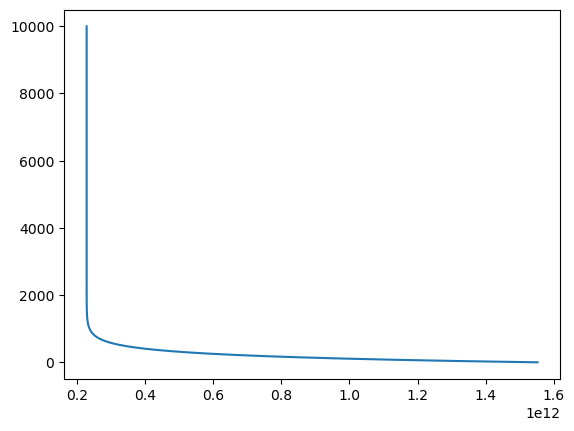

In [18]:
epochs = np.arange(10000)
plt.plot(error_list, epochs)

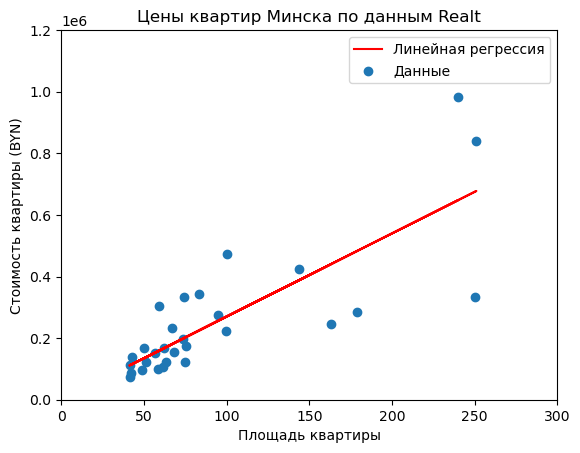

In [19]:
plt.plot(X, y_pred, color='red', label='Линейная регрессия')
plt.scatter(X, y, label='Данные')

plt.xlabel("Площадь квартиры")
plt.ylabel("Стоимость квартиры (BYN)")
plt.title("Цены квартир Минска по данным Realt")
plt.xlim(0, 300)
plt.ylim(0, 1200000)
plt.legend()

plt.show()